In [86]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# deep learning
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam

In [87]:
# ==============================
# STEP 2: LOAD DATASET
# ==============================

fd_001_train = pd.read_csv(
r"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\train_FD001.txt",
sep=" ",header=None)

fd_001_train.drop(columns=[26,27], inplace=True)

In [88]:
columns = [
'unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50',
'P2','P15','P30','Nf','Nc','epr','Ps30','phi','NRf','NRc','BPR','farB',
'htBleed','Nf_dmd','PCNfR_dmd','W31','W32'
]

fd_001_train.columns = columns

In [89]:
# dataset summary
print(fd_001_train.describe())

        unit_number  time_in_cycles     setting_1     setting_2      TRA  \
count  20631.000000    20631.000000  20631.000000  20631.000000  20631.0   
mean      51.506568      108.807862     -0.000009      0.000002    100.0   
std       29.227633       68.880990      0.002187      0.000293      0.0   
min        1.000000        1.000000     -0.008700     -0.000600    100.0   
25%       26.000000       52.000000     -0.001500     -0.000200    100.0   
50%       52.000000      104.000000      0.000000      0.000000    100.0   
75%       77.000000      156.000000      0.001500      0.000300    100.0   
max      100.000000      362.000000      0.008700      0.000600    100.0   

             T2           T24           T30           T50            P2  ...  \
count  20631.00  20631.000000  20631.000000  20631.000000  2.063100e+04  ...   
mean     518.67    642.680934   1590.523119   1408.933782  1.462000e+01  ...   
std        0.00      0.500053      6.131150      9.000605  5.329200e-15  ..

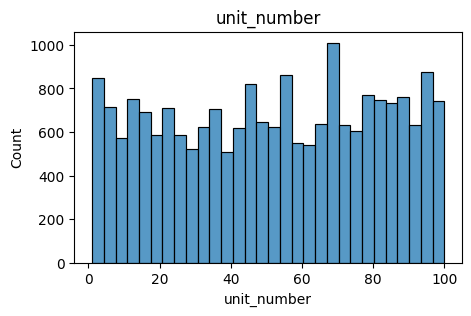

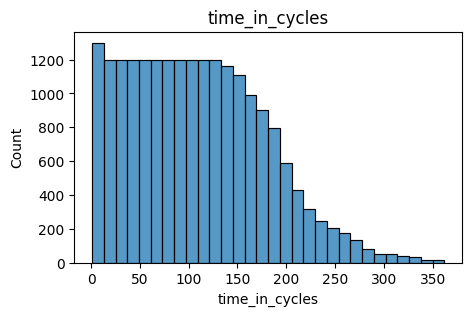

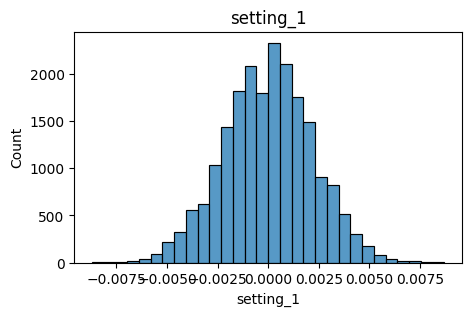

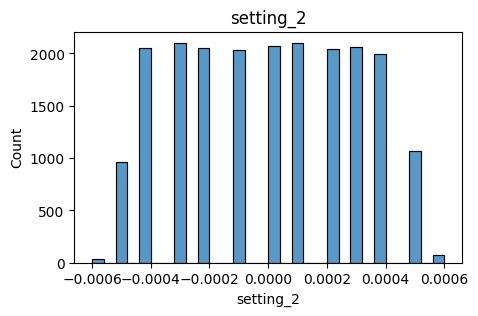

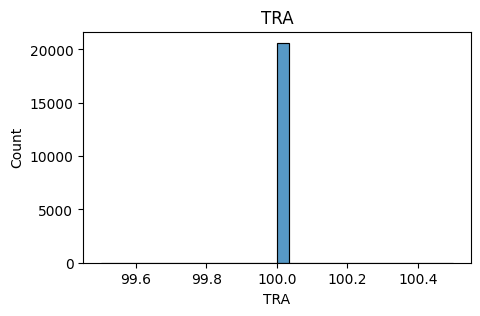

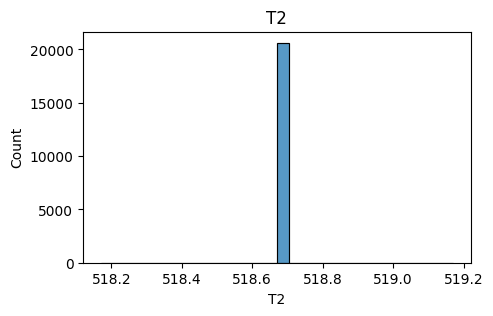

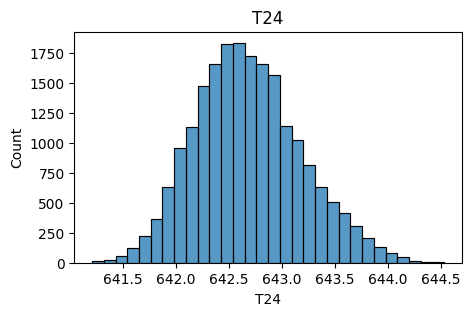

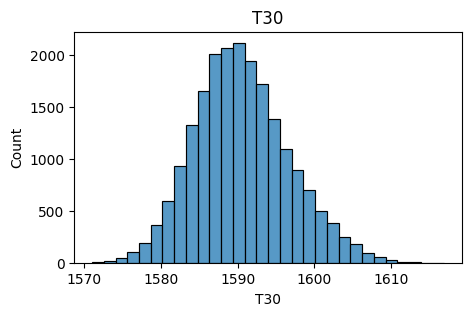

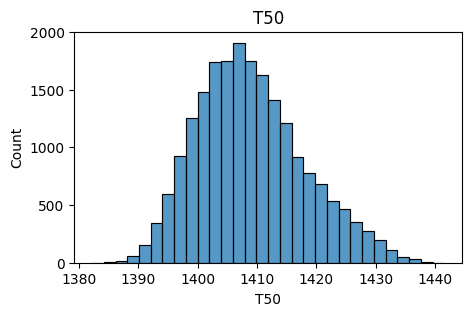

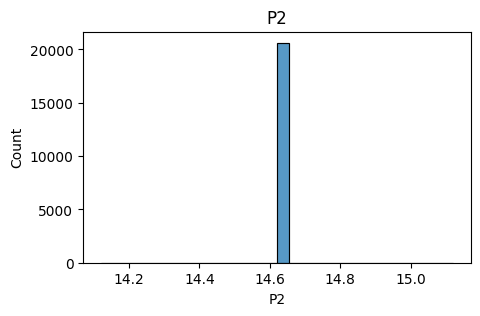

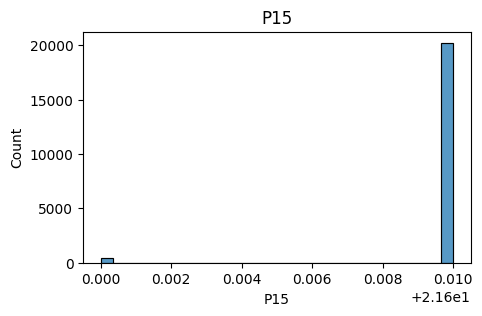

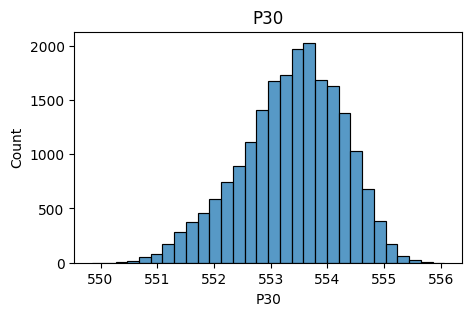

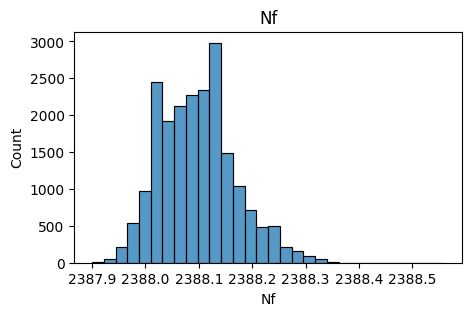

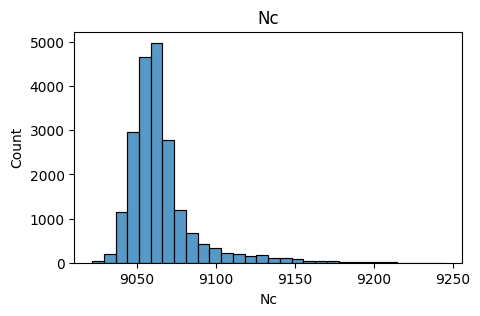

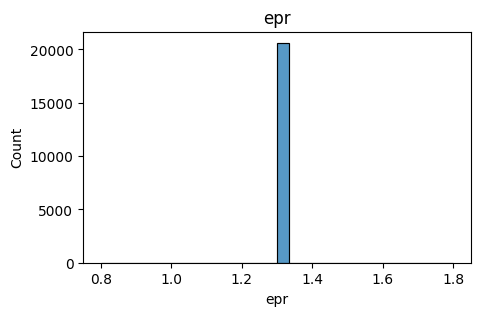

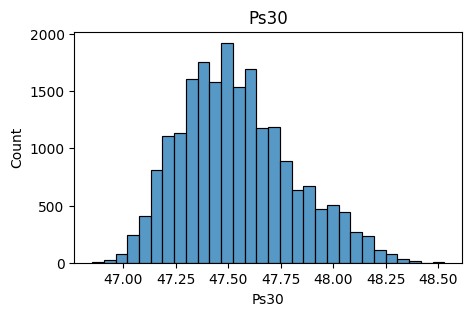

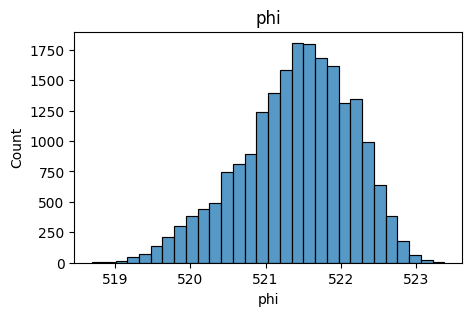

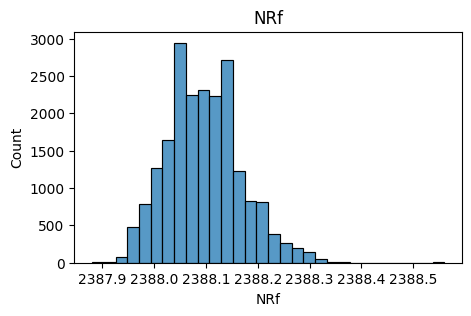

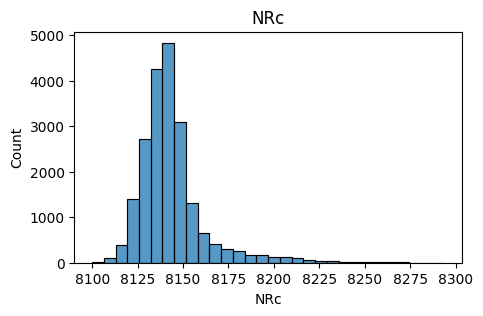

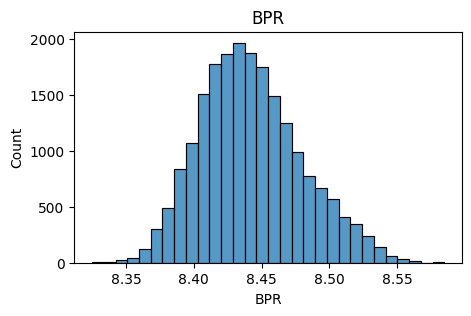

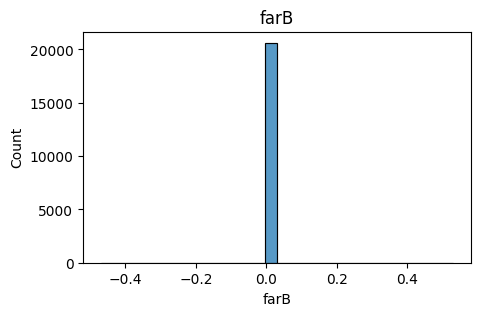

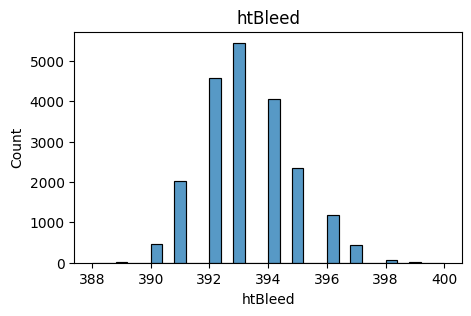

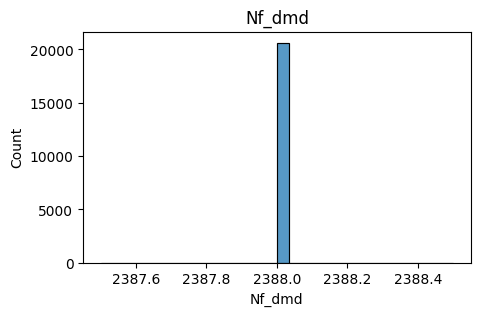

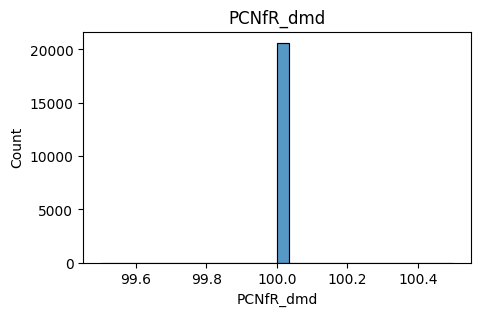

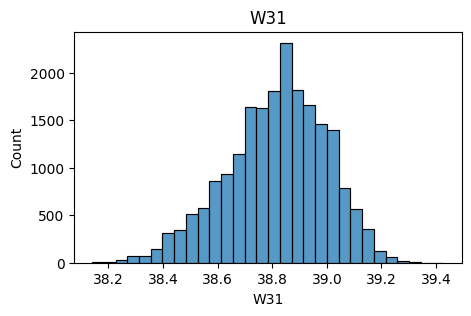

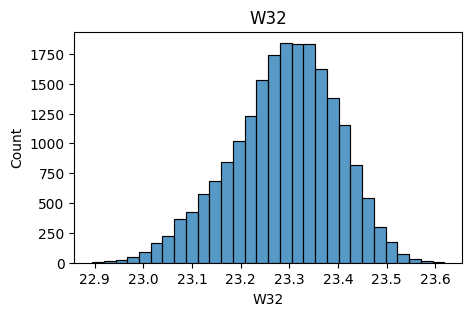

In [90]:

# histogram for sensors
for col in fd_001_train.columns:
    plt.figure(figsize=(5,3))
    sns.histplot(fd_001_train[col], bins=30)
    plt.title(col)
    plt.show()

In [91]:
fd_001_train.drop(columns=[
'Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'
], inplace=True)

In [92]:
sensor_data = fd_001_train.drop(columns=['unit_number','time_in_cycles'])

In [93]:
scaler = MinMaxScaler()

sensor_scaled = scaler.fit_transform(sensor_data)

sensor_scaled = pd.DataFrame(sensor_scaled,
columns=sensor_data.columns)

In [94]:
def create_sequences(data, seq_length):

    sequences = []

    for i in range(len(data) - seq_length):
        sequences.append(data.iloc[i:i+seq_length].values)

    return np.array(sequences)

sequence_length = 30

X_sequences = create_sequences(sensor_scaled, sequence_length)

print(X_sequences.shape)

(20601, 30, 17)


In [95]:
X_train, X_test = train_test_split(
X_sequences,
test_size=0.2,
random_state=42)

In [96]:
timesteps = X_train.shape[1]
features = X_train.shape[2]

input_layer = Input(shape=(timesteps, features))

# Encoder
encoded = LSTM(64, activation='relu', return_sequences=False)(input_layer)

# Latent representation
latent = RepeatVector(timesteps)(encoded)

# Decoder
decoded = LSTM(64, activation='relu', return_sequences=True)(latent)

output_layer = TimeDistributed(Dense(features))(decoded)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(
optimizer=Adam(learning_rate=0.001),
loss='mse'
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 30, 17)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_5 (RepeatVector)  │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 30, 17)         │         1,105 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,121 (215.32 KB)

 Trainable params: 55,121 (215.32 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
history = model.fit(
X_train,
X_train,
epochs=7,
batch_size=64,
validation_data=(X_test, X_test),
shuffle=True
)

Epoch 1/7
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.0287 - val_loss: 0.0121
Epoch 2/7
258/258 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0114 - val_loss: 0.0108
Epoch 3/7
258/258 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 0.0104 - val_loss: 0.0105
Epoch 4/7
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0102 - val_loss: 0.0102
Epoch 5/7
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0100 - val_loss: 0.0101
Epoch 6/7
258/258 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0098 - val_loss: 0.0096
Epoch 7/7
258/258 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0096 - val_loss: 0.0095


In [98]:
X_pred = model.predict(X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


In [99]:
reconstruction_error = np.mean(
np.power(X_test - X_pred, 2),
axis=(1,2)
)

print(reconstruction_error[:10])

[0.00751054 0.00863481 0.01295547 0.00836844 0.00936015 0.01004413
 0.00867252 0.00743817 0.00779815 0.01262299]


In [100]:
threshold = np.percentile(reconstruction_error, 95)
print("Threshold:", threshold)

Threshold: 0.014778925125205466


In [101]:
anomalies = reconstruction_error > threshold

print("Number of anomalies:", np.sum(anomalies))

Number of anomalies: 206


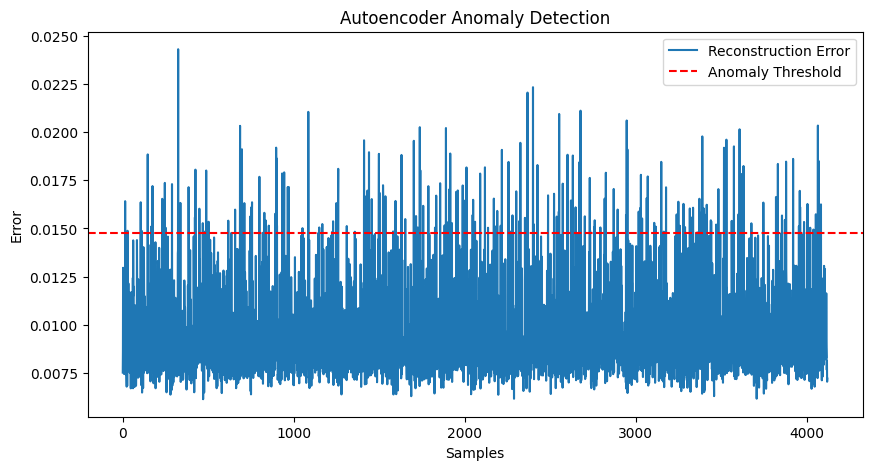

In [102]:
plt.figure(figsize=(10,5))

plt.plot(reconstruction_error, label="Reconstruction Error")

plt.axhline(threshold, color='red', linestyle='--',
label="Anomaly Threshold")

plt.xlabel("Samples")
plt.ylabel("Error")
plt.title("Autoencoder Anomaly Detection")

plt.legend()
plt.show()